# 504: Peak Warming vs Net-Zero CO2 Year

This notebook analyzes the relationship between peak warming (GSAT|ALL|peak) and the year of net-zero CO2 emissions.

In [17]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import matplotlib.pyplot as plt
import yaml

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])

# Load IPCC color palette
with open("ipcc_colors.yml") as f:
    IPCC_COLORS = yaml.safe_load(f)

In [18]:
# Load 503 metrics
metrics_df = pd.read_csv(OUTPUT_FOLDER / "503_warming_metrics.csv")
print(f"Loaded {len(metrics_df):,} runs")
metrics_df.head()

Loaded 409,800 runs


,Unnamed: 0,model,scenario,run_id,peak_year,GSAT|ALL|peak,GSAT|ALL|2100,GSAT|NonCO2_GHG|peak,GSAT|NonCO2_GHG|2100,GSAT|Residual|peak,...,GSAT|CO2_NZCO2|2100,GSAT|CO2_Negative|peak,GSAT|CO2_Negative|2100,GSAT|ALL|delta,GSAT|CO2_NZCO2|delta,GSAT|CO2_Negative|delta,GSAT|NonCO2_GHG|delta,GSAT|Residual|delta,year_netzero_co2,year_netzero_kyoto_ar6gwp100
0,0,AIM/CGE 2.0,SSP1-19,0,2049,1.612907,1.411091,0.092336,-0.093244,-0.041236,...,1.512313,0.000000,-0.065621,-0.201816,-0.049494,-0.065621,-0.185580,0.098879,2058.0,2073.0
1,1,AIM/CGE 2.0,SSP1-19,1,2093,2.592601,2.577173,0.438947,0.419883,-0.822595,...,3.072829,-0.071348,-0.096158,-0.015427,0.025233,-0.024810,-0.019064,0.003215,2058.0,2073.0
2,2,AIM/CGE 2.0,SSP1-19,2,2049,1.798363,1.577004,0.099817,-0.076595,0.046628,...,1.624423,0.000000,-0.069052,-0.221359,-0.027495,-0.069052,-0.176412,0.051601,2058.0,2073.0
3,3,AIM/CGE 2.0,SSP1-19,3,2038,1.379944,1.074082,0.098739,-0.197705,0.052872,...,1.158700,0.000000,-0.052731,-0.305862,-0.069634,-0.052731,-0.296443,0.112946,2058.0,2073.0
4,4,AIM/CGE 2.0,SSP1-19,4,2048,1.645092,1.396311,0.107123,-0.111821,-0.000573,...,1.480224,0.000000,-0.062936,-0.248781,-0.058318,-0.062936,-0.218945,0.091418,2058.0,2073.0


In [19]:
# Calculate median and percentiles of GSAT|ALL|peak per scenario
scenario_stats = metrics_df.groupby(["model", "scenario"]).agg({
    "GSAT|ALL|peak": [
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.33),
        "median",
        lambda x: x.quantile(0.67),
        lambda x: x.quantile(0.95)
    ],
    "year_netzero_co2": "first"  # same for all runs in a scenario
}).reset_index()

# Flatten column names
scenario_stats.columns = ["model", "scenario", "peak_p05", "peak_p33", "peak_median", "peak_p67", "peak_p95", "year_netzero_co2"]

print(f"Scenarios: {len(scenario_stats)}")
scenario_stats.head()

Scenarios: 683


,model,scenario,peak_p05,peak_p33,peak_median,peak_p67,peak_p95,year_netzero_co2
0,AIM/CGE 2.0,SSP1-19,1.185548,1.439749,1.543185,1.668978,2.102762,2058.0
1,AIM/CGE 2.0,SSP2-19,1.173956,1.414497,1.513349,1.630569,2.001557,2051.0
2,AIM/CGE 2.0,SSP2-26,1.268153,1.559657,1.705169,1.848341,2.486736,2072.0
3,AIM/CGE 2.0,SSP3-34,1.567666,1.902751,2.075617,2.262988,2.989553,2086.0
4,AIM/CGE 2.0,SSP4-26,1.259647,1.535367,1.656441,1.798768,2.313768,2080.0


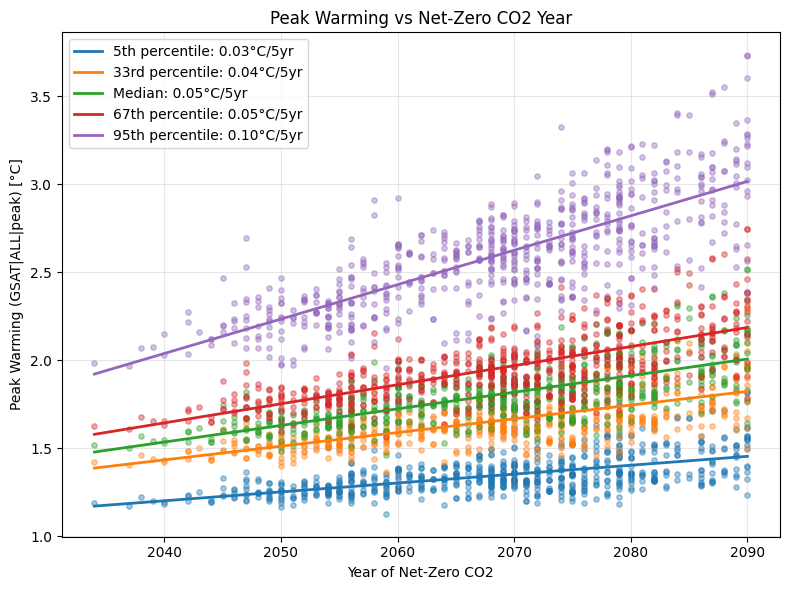

In [20]:
# Scatter plot: Peak warming vs net-zero CO2 year
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

x = scenario_stats["year_netzero_co2"]
mask = ~np.isnan(x)
x_fit = np.array([x.min(), x.max()])

# Plot each percentile with different colors
percentiles = [
    ("peak_p05", "5th percentile", IPCC_COLORS[2]),    # Dark Blue
    ("peak_p33", "33rd percentile", IPCC_COLORS[9]),   # Bright Green
    ("peak_median", "Median", IPCC_COLORS[0]),         # IPCC Blue
    ("peak_p67", "67th percentile", IPCC_COLORS[6]),   # Warm Mustard
    ("peak_p95", "95th percentile", IPCC_COLORS[3]),   # Warm Red
]

for col, label, color in percentiles:
    y = scenario_stats[col]
    
    ax.scatter(x, y, color=color, alpha=0.4, s=15)
    
    # Linear fit
    m = mask & ~np.isnan(y)
    slope, intercept = np.polyfit(x[m], y[m], 1)
    slope_per_5yr = slope * 5  # Convert to °C per 5 years
    ax.plot(x_fit, slope * x_fit + intercept, color=color, linewidth=2, 
            label=f"{label}: {slope_per_5yr:.2f}°C/5yr")

ax.set_xlabel("Year of Net-Zero CO2")
ax.set_ylabel("Peak Warming (GSAT|ALL|peak) [°C]")
ax.set_title("Peak Warming vs Net-Zero CO2 Year")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()